# UK Crime vs. Index of Multiple Deprivation

Correlating specific crime types from **data.police.uk** with each domain of the **English Indices
of Deprivation 2025** at LSOA level, then visualising with geopandas.

## 0. Setup

First the IMD, crime, and boundary data is loaded

In [2]:
# !pip install geopandas pandas matplotlib seaborn scipy mapclassify

import glob
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import config

IMD_PATH = config.IMD_DATA_PATH
POLICE_DIR  = config.POLICE_CRIME_DATA_DC
LSOA_PATH   = config.LSOA_DATA

pd.set_option("display.max_columns", 60)
plt.rcParams["figure.dpi"] = 110

## 1. Load IMD 2025 scores

This code loads and prepares the IMD dataset before combining it with the crime data. We are only looking at English LSOAs here. Income and employment scores are decimal fractions (0 to ~0.5 typically, the proportion of the population classed as deprived on that measure), while education and health scores are on different, larger scales because they're built from different underlying indicators. This is why direct comparison of scores across domains is misleading and why correlation analysis ranks them instead.

In [3]:
imd_raw = pd.read_csv(IMD_PATH)
print("Shape:", imd_raw.shape)
print("LSOA prefix counts (should be all 'E'):", #this is such that all rows are English and none from Wales or elsewhere
      imd_raw["LSOA code"].str[0].value_counts().to_dict())

domain_cols = {
    "LSOA code":                                       "LSOA21CD",
    "Index of Multiple Deprivation Score":             "imd",
    "Income Score":                                    "income",
    "Employment Score":                                "employment",
    "Education Skills and Training Score":             "education",
    "Health Deprivation and Disability Score":         "health",
    "Crime Score":                                     "crime_imd",
    "Barriers to Housing and Services Score":          "barriers",
    "Living Environment Score":                        "living_env",
    "Total population":                                "population",
}
imd = imd_raw[list(domain_cols)].rename(columns=domain_cols)
imd.head()

Shape: (33755, 56)
LSOA prefix counts (should be all 'E'): {'E': 33755}


,LSOA21CD,imd,income,employment,education,health,crime_imd,barriers,living_env,population
0,E01000001,8.742,0.013,0.014,0.004,-1.771,-2.220,10.950,69.345,1795
1,E01000002,4.722,0.018,0.010,0.169,-1.549,-2.277,6.703,43.890,1671
2,E01000003,9.250,0.107,0.064,3.269,-0.292,-0.765,9.735,41.163,1896
3,E01000005,19.884,0.211,0.104,17.852,0.436,-0.626,24.623,38.695,1737
4,E01000006,25.307,0.343,0.120,25.442,-0.372,-0.072,38.025,29.616,1837


## 2. Load police crime data

This code loads all police crime CSV files into one large dataset. Longitude and latitude aren't actually used in the analysis (only the LSOA code), but kept if anything wants to be done with coordinates in the future. If needed, for further analysis, the data could be split into different timeframes than months to spot e.g. seasonality.

In [4]:
files = sorted(glob.glob(str(POLICE_DIR / "**" / "*-street.csv"), recursive=True))
print(f"Found {len(files)} CSV files")
assert len(files) > 0, "No CSVs found — double-check POLICE_DIR"

usecols = ["Month", "Longitude", "Latitude", "LSOA code", "Crime type"]

crimes = pd.concat(
    (pd.read_csv(f, usecols=usecols, low_memory=False) for f in files),
    ignore_index=True,
)
print(f"Total records: {len(crimes):,}")
crimes.head()


Found 513 CSV files
Total records: 5,881,375


,Month,Longitude,Latitude,LSOA code,Crime type
0,2025-01,-1.084621,53.251666,E01033769,Violence and sexual offences
1,2025-01,-2.511824,51.411782,E01014399,Criminal damage and arson
2,2025-01,-2.508867,51.416147,E01014399,Violence and sexual offences
3,2025-01,-2.508867,51.416147,E01014399,Violence and sexual offences
4,2025-01,-2.508867,51.416147,E01014399,Violence and sexual offences


## 3. Aggregate crime by LSOA × crime type

This code filters the crime data to England and aggregates crimes by LSOA and crime type. The table shows the amount of each crime type per LSOA per year.

In [5]:
crimes_eng = (
    crimes.dropna(subset=["LSOA code"])
          .loc[lambda d: d["LSOA code"].str.startswith("E")]
          .copy()
)
print(f"England-only records: {len(crimes_eng):,}")
print("\nCrime type breakdown:")
print(crimes_eng["Crime type"].value_counts())

counts = (
    crimes_eng.groupby(["LSOA code", "Crime type"]).size()
    .unstack(fill_value=0)
    .rename_axis(index="LSOA21CD", columns=None)
    .reset_index()
)
print("\nCounts table shape:", counts.shape)
counts.head()

England-only records: 5,382,577

Crime type breakdown:
Crime type
Violence and sexual offences    1878485
Anti-social behaviour            871508
Shoplifting                      448892
Criminal damage and arson        385599
Public order                     365489
Other theft                      361083
Vehicle crime                    279978
Burglary                         200733
Drugs                            190093
Other crime                      116787
Theft from the person            110962
Robbery                           74053
Possession of weapons             51845
Bicycle theft                     47070
Name: count, dtype: int64

Counts table shape: (32464, 15)


,LSOA21CD,Anti-social behaviour,Bicycle theft,Burglary,Criminal damage and arson,Drugs,Other crime,Other theft,Possession of weapons,Public order,Robbery,Shoplifting,Theft from the person,Vehicle crime,Violence and sexual offences
0,E01000001,8,18,6,10,10,3,44,0,7,3,9,46,11,17
1,E01000002,12,73,11,18,14,2,103,0,33,9,117,60,6,46
2,E01000003,12,13,16,7,66,1,18,0,8,6,1,20,1,36
3,E01000005,22,28,56,37,36,2,154,3,65,22,182,88,18,156
4,E01000006,22,0,3,4,2,5,11,1,6,2,0,4,6,40


## 4. Load LSOA 2021 boundaries

This code loads the LSOA boundary map and prepares it for spatial analysis and visualisation. The output of amount of LSOAs is 35672 (instead of the earlier 33755), this is because the map shows England + Wales, but later on only England is visualized.

In [6]:
lsoa = gpd.read_file(LSOA_PATH)

code_col = next(c for c in lsoa.columns if c.upper().startswith("LSOA21CD"))
lsoa = lsoa[[code_col, "geometry"]].rename(columns={code_col: "LSOA21CD"})

lsoa = lsoa.to_crs(epsg=27700)
print(lsoa.shape, "CRS:", lsoa.crs.name)
lsoa.head()

(35672, 2) CRS: OSGB36 / British National Grid


,LSOA21CD,geometry
0,E01000001,"POLYGON ((532107.114 182010.82, 532164.292 181..."
1,E01000002,"POLYGON ((532636.307 181926.254, 532620.95 181..."
2,E01000003,"POLYGON ((532136.943 182198.381, 532160.055 18..."
3,E01000005,"POLYGON ((533809.836 180767.973, 533650.852 18..."
4,E01000006,"POLYGON ((545123.925 184315.103, 545273.727 18..."


## 5. Merge everything in one GeoDataFrame

This code combines the map, deprivation data, and crime counts into one GeoDataFrame on LSOA code. Then it calculates crime rates per 1,000 residents. If no certain crime type has been recorded the table gives value 0.

In [7]:
gdf = (
    lsoa.merge(imd,    on="LSOA21CD", how="left")
        .merge(counts, on="LSOA21CD", how="left")
)

imd_domains = ["imd", "income", "employment", "education", "health",
               "crime_imd", "barriers", "living_env"]
non_crime   = {"LSOA21CD", "geometry", "population"} | set(imd_domains)
crime_types = [c for c in gdf.columns if c not in non_crime]

# LSOAs with no recorded crime of a given type give 0, not NaN
gdf[crime_types] = gdf[crime_types].fillna(0)

# Counts --> annual rate per 1,000 residents 
N_MONTHS = 12
for c in crime_types:
    gdf[c + "_rate"] = gdf[c] / gdf["population"] * 1000 * (12 / N_MONTHS)

rate_cols = [c + "_rate" for c in crime_types]
print(f"{len(crime_types)} crime types in the data:")
for c in crime_types: print("  •", c)
gdf[["LSOA21CD", "population", "imd", "income"] + rate_cols[:3]].head()

14 crime types in the data:
  • Anti-social behaviour
  • Bicycle theft
  • Burglary
  • Criminal damage and arson
  • Drugs
  • Other crime
  • Other theft
  • Possession of weapons
  • Public order
  • Robbery
  • Shoplifting
  • Theft from the person
  • Vehicle crime
  • Violence and sexual offences


,LSOA21CD,population,imd,income,Anti-social behaviour_rate,Bicycle theft_rate,Burglary_rate
0,E01000001,1795.0,8.742,0.013,4.456825,10.027855,3.342618
1,E01000002,1671.0,4.722,0.018,7.181329,43.686415,6.582885
2,E01000003,1896.0,9.250,0.107,6.329114,6.856540,8.438819
3,E01000005,1737.0,19.884,0.211,12.665515,16.119747,32.239493
4,E01000006,1837.0,25.307,0.343,11.976048,0.000000,1.633097


## 6. Correlations Analysis

Spearman's rank correlation (ρ) was used because crime rates are highly right-skewed and the IMD domains are measured on different scales. Instead of using the raw values, Spearman ranks each variable and correlates the ranks, making it robust to non-normal data and outliers.

For each crime type and deprivation domain, a Spearman correlation and p-value were calculated. Because 112 comparisons were performed (14 crime types × 8 domains), a Bonferroni correction was applied to reduce the risk of false positives. Practical significance was assessed using ρ², which measures the proportion of shared rank variance between crime and deprivation.

In [8]:
analysis = gdf[imd_domains + rate_cols].replace([np.inf, -np.inf], np.nan).dropna()
print(f"LSOAs in analysis: {len(analysis):,}")

def spearman_with_p(df, rows, cols):
    rho  = pd.DataFrame(index=rows, columns=cols, dtype=float)
    pval = pd.DataFrame(index=rows, columns=cols, dtype=float)
    for r in rows:
        for c in cols:
            sub = df[[r, c]].dropna()
            res = stats.spearmanr(sub[r], sub[c])
            rho.loc[r, c]  = res.correlation
            pval.loc[r, c] = res.pvalue
    return rho, pval

rho, pval = spearman_with_p(analysis, rate_cols, imd_domains)
rho.index  = [c.replace("_rate", "") for c in rho.index]
pval.index = rho.index

from statsmodels.stats.multitest import multipletests

#Bonferroni correction
n_tests = pval.size                  
alpha   = 0.05
alpha_bonf = alpha / n_tests
print(f"Number of comparisons: {n_tests}")
print(f"Bonferroni-adjusted α threshold: {alpha_bonf:.2e}")

_, pvals_corrected, _, _ = multipletests(
    pval.values.flatten(), alpha=alpha, method="bonferroni"
)
pval_bonf = pd.DataFrame(
    pvals_corrected.reshape(pval.shape),
    index=pval.index, columns=pval.columns,
)

annot = rho.round(2).astype(str)
annot = annot.mask(pval_bonf < 0.001, annot + "**")                        #robustly significant
annot = annot.mask((pval_bonf >= 0.001) & (pval_bonf < 0.05), annot + "*") #significant after correction

n_sig_raw  = (pval      < 0.05).sum().sum()
n_sig_bonf = (pval_bonf < 0.05).sum().sum()
print(f"Significant before correction: {n_sig_raw} / {n_tests}")
print(f"Significant after Bonferroni:  {n_sig_bonf} / {n_tests}")

#ρ² as an effect-size summary
rho_sq = rho ** 2
print("\nρ² (squared Spearman correlation — shared rank-variance):")
print(rho_sq.round(3))

annot   #display the table with corrected stars

LSOAs in analysis: 33,755
Number of comparisons: 112
Bonferroni-adjusted α threshold: 4.46e-04
Significant before correction: 111 / 112
Significant after Bonferroni:  107 / 112

ρ² (squared Spearman correlation — shared rank-variance):
                                imd  income  employment  education  health  \
Anti-social behaviour         0.140   0.157       0.121      0.072   0.089   
Bicycle theft                 0.048   0.051       0.029      0.013   0.033   
Burglary                      0.061   0.049       0.035      0.012   0.026   
Criminal damage and arson     0.260   0.236       0.236      0.206   0.207   
Drugs                         0.200   0.211       0.163      0.115   0.126   
Other crime                   0.166   0.147       0.159      0.163   0.157   
Other theft                   0.140   0.125       0.094      0.063   0.070   
Possession of weapons         0.147   0.139       0.133      0.128   0.130   
Public order                  0.186   0.176       0.165      0

,imd,income,employment,education,health,crime_imd,barriers,living_env
Anti-social behaviour,0.37**,0.4**,0.35**,0.27**,0.3**,0.46**,0.03**,0.17**
Bicycle theft,0.22**,0.23**,0.17**,0.11**,0.18**,0.33**,-0.07**,0.23**
Burglary,0.25**,0.22**,0.19**,0.11**,0.16**,0.32**,0.01,0.3**
Criminal damage and arson,0.51**,0.49**,0.49**,0.45**,0.45**,0.57**,-0.02,0.17**
Drugs,0.45**,0.46**,0.4**,0.34**,0.36**,0.51**,0.02*,0.25**
Other crime,0.41**,0.38**,0.4**,0.4**,0.4**,0.43**,-0.03**,0.06**
Other theft,0.37**,0.35**,0.31**,0.25**,0.26**,0.44**,0.07**,0.29**
Possession of weapons,0.38**,0.37**,0.36**,0.36**,0.36**,0.43**,-0.03**,0.11**
Public order,0.43**,0.42**,0.41**,0.36**,0.39**,0.53**,-0.07**,0.18**
Robbery,0.36**,0.38**,0.31**,0.23**,0.28**,0.46**,-0.02,0.29**


This code below visualises the Spearman correlation matrix produced in the previous step as a heatmap, using the Bonferroni-corrected significance markers to indicate which relationships are statistically significant.

Deep blue = strong negative relationship

White = no relationship

Dark red = strong postive relationship 

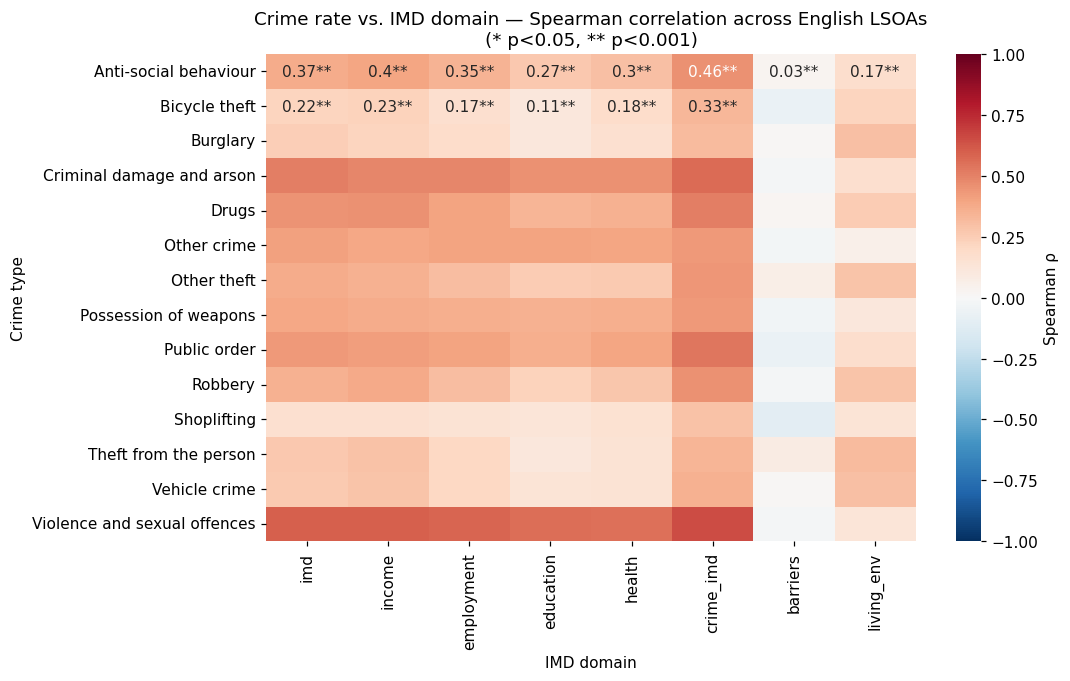

In [9]:
fig, ax = plt.subplots(figsize=(10, max(6, 0.45 * len(rho))))
sns.heatmap(
    rho.astype(float),
    annot=annot, fmt="",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    cbar_kws={"label": "Spearman ρ"},
    ax=ax,
)
ax.set_title("Crime rate vs. IMD domain — Spearman correlation across English LSOAs\n"
             "(* p<0.05, ** p<0.001)")
ax.set_xlabel("IMD domain")
ax.set_ylabel("Crime type")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

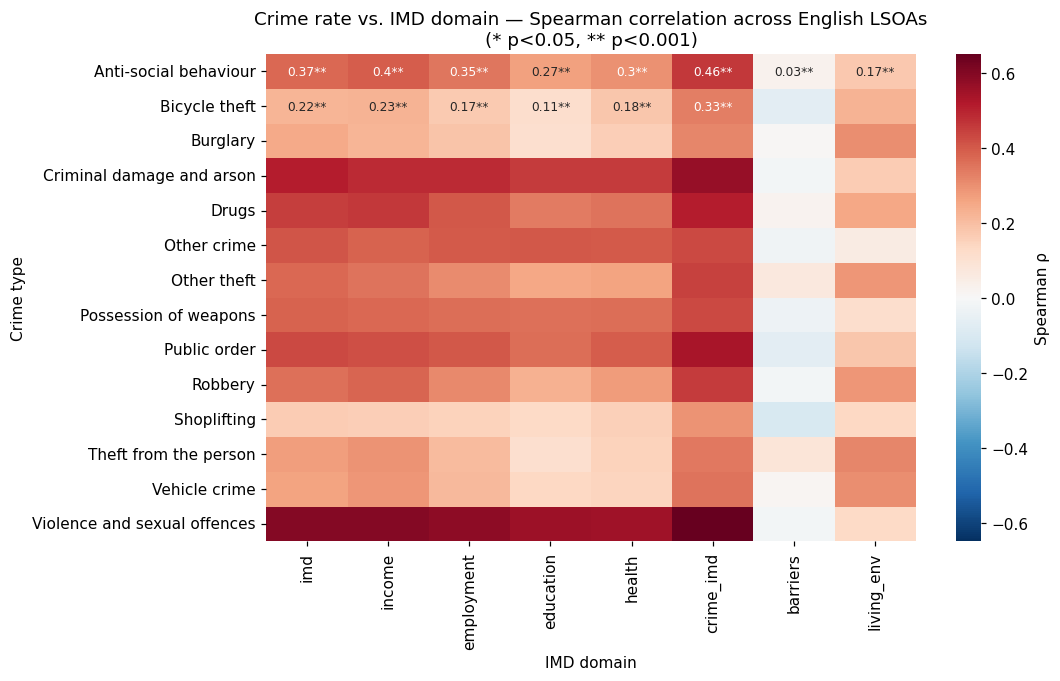

In [14]:
fig, ax = plt.subplots(figsize=(10, max(6, 0.45 * len(rho))))
sns.heatmap(
    rho.astype(float),
    annot=annot, fmt="",
    cmap="RdBu_r", center=0,
    vmin=-0.65, vmax=0.65,          # <-- only change: was vmin=-1, vmax=1
    annot_kws={"size": 8},          # optional: keeps all the numbers legible
    cbar_kws={"label": "Spearman ρ"},
    ax=ax,
)
ax.set_title("Crime rate vs. IMD domain — Spearman correlation across English LSOAs\n"
             "(* p<0.05, ** p<0.001)")
ax.set_xlabel("IMD domain")
ax.set_ylabel("Crime type")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Choropleth: England-wide side-by-side

This code creates two side-by-side choropleth maps of England:

**1.** A map showing the rate of a selectred crime type (e.g. violence and sexual offences)\
**2.** A map showing a selected deprivation domain (e.g. income deprivation)

The main purpose of this approach is to visually validate and communicate the correlation results.

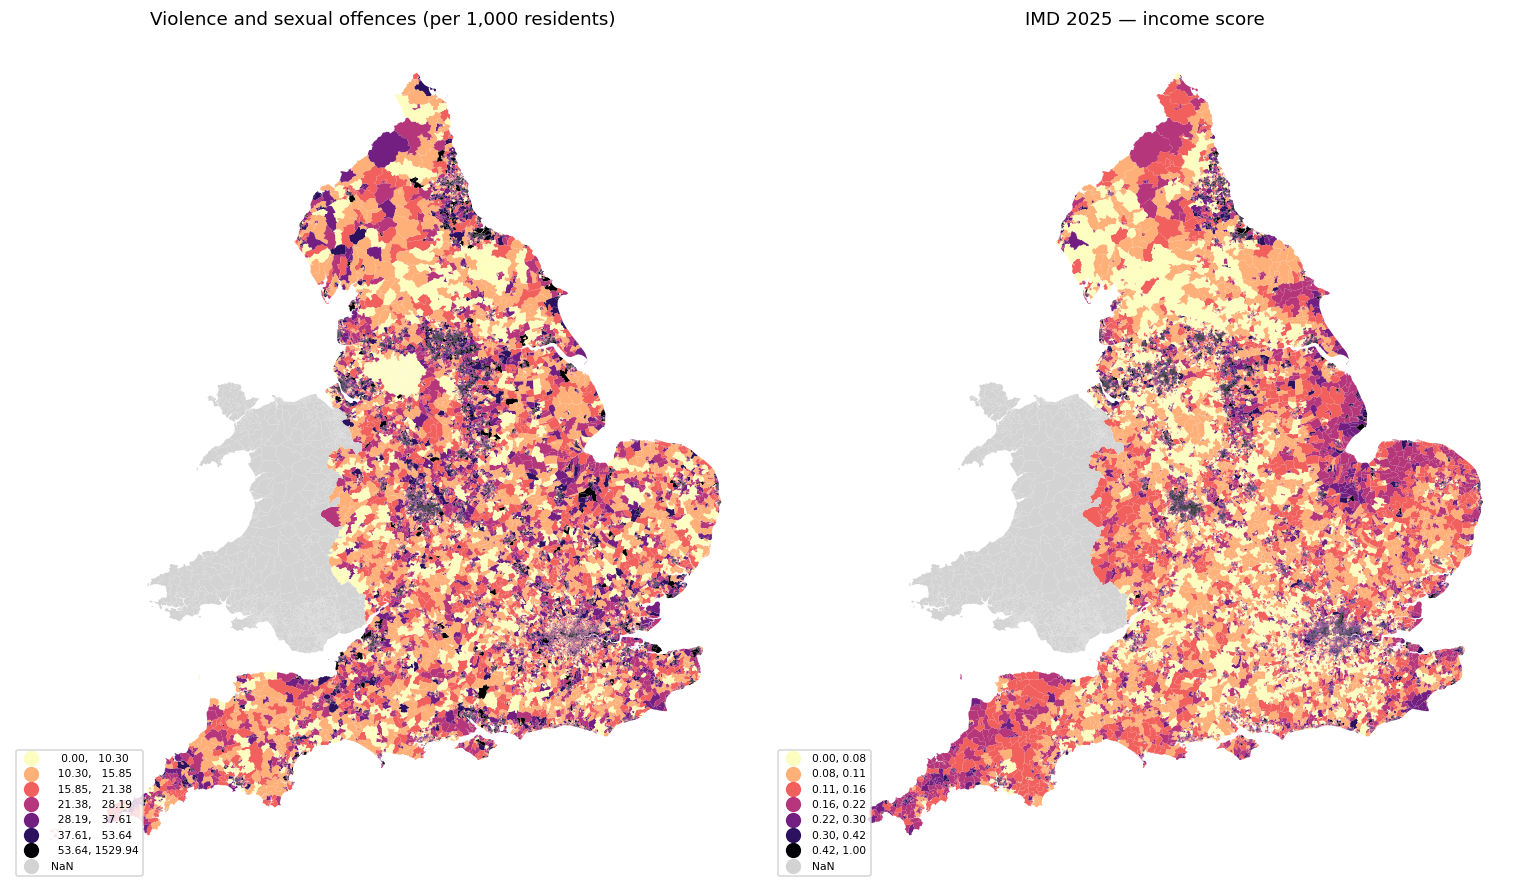

In [11]:
#Choose what to plot: can be changed
CRIME  = "Violence and sexual offences_rate"
DOMAIN = "income"

assert CRIME  in gdf.columns, f"{CRIME} not found. Available: {rate_cols}"
assert DOMAIN in gdf.columns, f"{DOMAIN} not found. Available: {imd_domains}"

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
for ax, col, title in [
    (axes[0], CRIME,  f"{CRIME.replace('_rate','')} (per 1,000 residents)"),
    (axes[1], DOMAIN, f"IMD 2025 — {DOMAIN} score"),
]:
    gdf.plot(
        column=col, scheme="quantiles", k=7,
        cmap="magma_r", linewidth=0, ax=ax, legend=True,
        legend_kwds={"loc": "lower left", "fontsize": 7},
        missing_kwds={"color": "lightgrey"},
    )
    ax.set_title(title)
    ax.set_axis_off()

plt.tight_layout()
plt.savefig("choropleth_england.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. City zoom

This code creates the same type of side-by-side choropleth maps as before, but instead of showing all of England, it zooms in on a selected geographic area (here, Greater London). The England-wide map is useful for identifying broad national patterns, but it can hide local variation because thousands of LSOAs are shown at once. The city zoom allows for seeing differences between neighbourhoods within the same city (e.g. compare city centres and suburbs in more detail).

Useful BNG bounding boxes to try:
- Greater Manchester: `(370000, 385000, 410000, 415000)`
- Greater London: `(503000, 155000, 562000, 200000)`
- Birmingham: `(395000, 280000, 425000, 300000)`
- Liverpool/Merseyside: `(330000, 380000, 365000, 405000)`

LSOAs in window: 5775


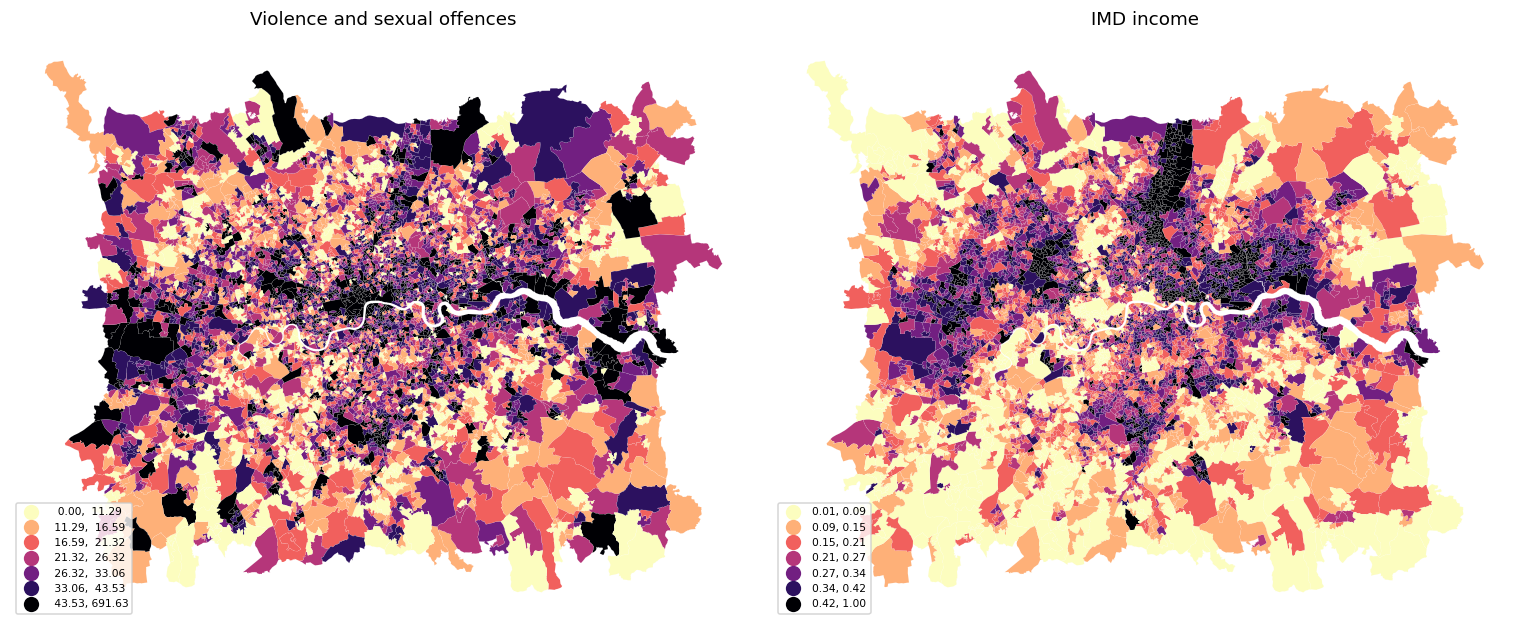

In [12]:
minx, miny, maxx, maxy = 503000, 155000, 562000, 200000
city = gdf.cx[minx:maxx, miny:maxy]
print(f"LSOAs in window: {len(city)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, col, title in [
    (axes[0], CRIME,  CRIME.replace('_rate','')),
    (axes[1], DOMAIN, f"IMD {DOMAIN}"),
]:
    city.plot(
        column=col, scheme="quantiles", k=7,
        cmap="magma_r", linewidth=0.05, edgecolor="white",
        ax=ax, legend=True, legend_kwds={"loc": "lower left", "fontsize": 7},
    )
    ax.set_title(title); ax.set_axis_off()
plt.tight_layout()
plt.savefig("choropleth_city.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Scatter grid: one crime type vs every domain

This code creates a grid of scatter plots showing how one selected crime type relates to each IMD deprivation domain. The scatter plots, in contrary to the heatmap, show the shape of the relationships.

For example in the case of violence and sexual offence:
The shape of the relationships is generally upward-sloping but not perfectly linear. For the socio-economic domains, the point clouds widen as deprivation increases, indicating that highly deprived areas can experience either moderate or very high violence rates, while low-deprivation areas almost never experience the highest crime rates. This creates a fan-shaped pattern, suggesting that deprivation increases the likelihood of high crime but does not fully determine it. In contrast, the barriers and living environment domains show diffuse, largely horizontal clouds with little visible structure, consistent with their weak correlations.

(Y-axis is on a log scale because crime rates are zero-inflated and long-tailed; the structure is
invisible on a linear axis)

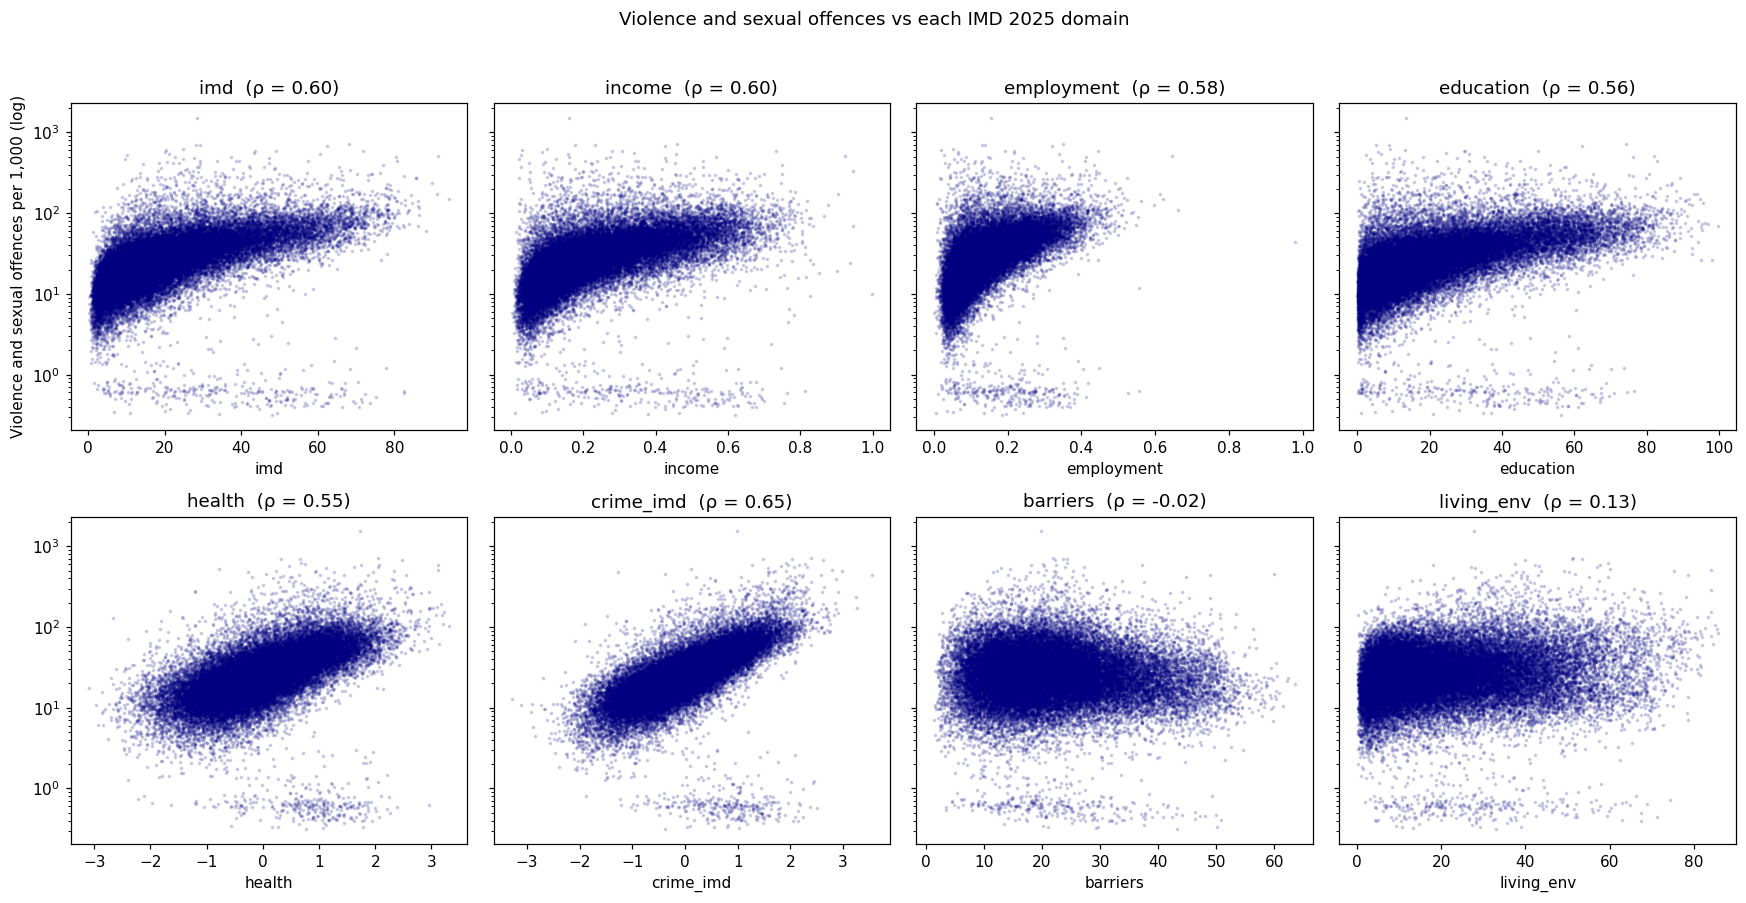

In [13]:
CRIME_FOR_SCATTER = CRIME  

fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=True)
for ax, dom in zip(axes.flat, imd_domains):
    sub = analysis[[CRIME_FOR_SCATTER, dom]].replace(0, np.nan).dropna()
    ax.scatter(sub[dom], sub[CRIME_FOR_SCATTER], s=2, alpha=0.15, color="navy")
    r = rho.loc[CRIME_FOR_SCATTER.replace("_rate", ""), dom]
    ax.set_title(f"{dom}  (ρ = {r:.2f})")
    ax.set_xlabel(dom)
    ax.set_yscale("log")
axes[0, 0].set_ylabel(f"{CRIME_FOR_SCATTER.replace('_rate','')} per 1,000 (log)")
fig.suptitle(f"{CRIME_FOR_SCATTER.replace('_rate','')} vs each IMD 2025 domain", y=1.02)
plt.tight_layout()
plt.savefig("scatter_grid.png", dpi=150, bbox_inches="tight")
plt.show()
